In [2]:
# 전체 패키지 체크
import os
import math
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
import PIL
from PIL import Image
import albumentations
from albumentations import  HorizontalFlip, RandomSizedCrop, Compose, OneOf, Resize

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

import skimage
from skimage.io import imread
from skimage.transform import resize

print('=3')

=3


In [12]:
!export PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True

In [5]:
!python3 train_unet.py

/home/jovyan/work/AIFFEL_quest_rs/GoingDeeper/Segmentation/dataset.py:24: UserWarning: Argument(s) 'height, width' are not valid for transform RandomSizedCrop
  RandomSizedCrop(  # 50%의 확률로 RandomSizedCrop
[UNet] Epoch 1/50 | train_loss=0.7185 train_dice=0.3277 | val_loss=0.6846 val_dice=0.3760
  -> best model saved (val_dice=0.3760) to ./checkpoints/unet_best.pth
[UNet] Epoch 2/50 | train_loss=0.6993 train_dice=0.0469 | val_loss=0.6619 val_dice=0.0001
[UNet] Epoch 3/50 | train_loss=0.6675 train_dice=0.0648 | val_loss=0.6455 val_dice=0.0000
[UNet] Epoch 4/50 | train_loss=0.6163 train_dice=0.1000 | val_loss=0.5032 val_dice=0.0000
[UNet] Epoch 5/50 | train_loss=0.5069 train_dice=0.1002 | val_loss=0.4454 val_dice=0.0002
[UNet] Epoch 6/50 | train_loss=0.4640 train_dice=0.4081 | val_loss=0.4606 val_dice=0.6865
  -> best model saved (val_dice=0.6865) to ./checkpoints/unet_best.pth
[UNet] Epoch 7/50 | train_loss=0.4048 train_dice=0.6490 | val_loss=0.3922 val_dice=0.6866
  -> best model saved 

In [14]:
!python3 train_unetpp.py

[UNet++] BATCH_SIZE=4, GRAD_ACCUM_STEPS=4 (effective batch=16), AMP=True, device=cuda
[UNet++] Epoch 1/50 | train_loss=0.7017 train_dice=0.2404 | val_loss=0.6569 val_dice=0.0003
  -> best model saved (val_dice=0.0003) to ./checkpoints/unetpp_best.pth
[UNet++] Epoch 2/50 | train_loss=0.6508 train_dice=0.0178 | val_loss=0.6308 val_dice=0.0002
[UNet++] Epoch 3/50 | train_loss=0.5588 train_dice=0.0151 | val_loss=0.5566 val_dice=0.0296
  -> best model saved (val_dice=0.0296) to ./checkpoints/unetpp_best.pth
[UNet++] Epoch 4/50 | train_loss=0.4804 train_dice=0.4280 | val_loss=0.4234 val_dice=0.6849
  -> best model saved (val_dice=0.6849) to ./checkpoints/unetpp_best.pth
[UNet++] Epoch 5/50 | train_loss=0.4389 train_dice=0.6214 | val_loss=0.4166 val_dice=0.7128
  -> best model saved (val_dice=0.7128) to ./checkpoints/unetpp_best.pth
[UNet++] Epoch 6/50 | train_loss=0.4214 train_dice=0.6417 | val_loss=0.4107 val_dice=0.7433
  -> best model saved (val_dice=0.7433) to ./checkpoints/unetpp_best.p

In [7]:
!python3 inference_unet.py

/home/jovyan/work/AIFFEL_quest_rs/GoingDeeper/Segmentation/dataset.py:24: UserWarning: Argument(s) 'height, width' are not valid for transform RandomSizedCrop
  RandomSizedCrop(  # 50%의 확률로 RandomSizedCrop
[UNet] Loaded checkpoint: ./checkpoints/unet_best.pth (epoch=18, val_dice=0.8472)
[UNet] mIoU on labeled holdout (30 images): 0.7595
  Top-1: IoU=0.9345  image=000191_10.png -> ./inference_results/unet/top_k/top1_iou0.9345.png
  Top-2: IoU=0.9219  image=000190_10.png -> ./inference_results/unet/top_k/top2_iou0.9219.png
  Top-3: IoU=0.9183  image=000184_10.png -> ./inference_results/unet/top_k/top3_iou0.9183.png
[UNet] Saved 0 inference visualizations (no GT) to ./inference_results/unet/unlabeled_testing


In [15]:
!python3 inference_unetpp.py

[UNet++] Loaded checkpoint: ./checkpoints/unetpp_best.pth (epoch=20, val_dice=0.8326)
[UNet++] mIoU on labeled holdout (30 images): 0.7506
  Top-1: IoU=0.9556  image=000183_10.png -> ./inference_results/unetpp/top_k/top1_iou0.9556.png
  Top-2: IoU=0.9430  image=000185_10.png -> ./inference_results/unetpp/top_k/top2_iou0.9430.png
  Top-3: IoU=0.9418  image=000181_10.png -> ./inference_results/unetpp/top_k/top3_iou0.9418.png
[UNet++] Saved 0 inference visualizations (no GT) to ./inference_results/unetpp/unlabeled_testing


In [17]:
!python3 visualize.py

Saved training curve plot to ./checkpoints/unet_training_curve.png
Figure(1200x400)
Saved training curve plot to ./checkpoints/unetpp_training_curve.png
Figure(1200x400)
Saved comparison plot to ./checkpoints/compare_val_dice.png
Figure(600x400)
Figure(1200x400)


UNet++(위), UNet(아래) inference 결과

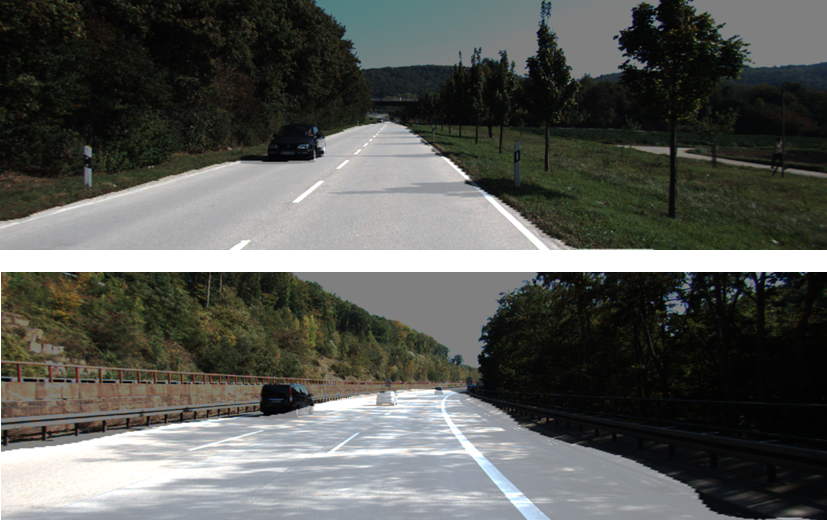

# Semantic Segmentation 실험 방법 정리 (UNet vs UNet++)

## 1. 개요

KITTI semantic segmentation 데이터셋을 이용해 **UNet**과 **UNet++** 두 모델을 동일한 조건(입력 크기, loss, optimizer, epoch 등)에서 학습하고, held-out 평가셋과 실제 라벨 없는 testing set에 대해 추론 결과를 비교한다.

---

## 2. 데이터셋

### 2.1 데이터 구성

| 구분 | 경로 | 라벨 유무 | 용도 |
|---|---|---|---|
| Train / Val(holdout) | `~/work/semantic_segmentation/data/training` (`image_2/`, `semantic/`) | 있음 | 학습 및 검증 |
| Real Test | `~/work/semantic_segmentation/data/testing` (`images_2/`) | **없음** | 정성적 추론(시각화)만 가능 |

- `training` 폴더의 전체 쌍(이미지-라벨) 중 **마지막 30장을 holdout(test_dataset)**으로 분리하여 학습 중 검증 및 최종 정량 평가(mIoU)에 사용한다.
- `testing` 폴더는 `images_2/`만 존재하고 정답 라벨이 없어 **IoU/mIoU 계산이 불가능**하다. 따라서 이 데이터는 순수 추론(오버레이 시각화) 결과 확인 용도로만 사용한다.

### 2.2 라벨 정의

- KITTI semantic 라벨 중 특정 클래스 값(`== 7`, 도로(road) 클래스)만 이진 마스크(0/1)로 변환하여 사용한다.
- 즉 본 실험은 **다중 클래스 분할이 아닌, 단일 클래스(도로) 이진 분할** 문제로 설정되어 있다.

### 2.3 전처리 및 Augmentation (`albumentations`)

| 구분 | 적용 기법 |
|---|---|
| Train | `HorizontalFlip(p=0.5)` → `RandomSizedCrop(min_max_height=(300,370), size=(224,224), p=0.5)` → `Resize(224,224)` |
| Test / Val | `Resize(224,224)`만 적용 |

- 이미지는 `/255.0`으로 정규화 후 `(H,W,C) → (C,H,W)`로 변환하여 텐서화한다.
- 마스크는 이미지와 동일한 geometric transform이 적용되며, 채널 차원을 `(1,H,W)`로 확장한다.
- 매 epoch 종료 시 `KittiDataset.shuffle_data()`를 호출하여 학습 데이터 순서를 셔플한다.

---

## 3. 모델 구조

| 항목 | UNet | UNet++ |
|---|---|---|
| Encoder depth | 4 (64→128→256→512→1024) | 4 (동일, `base_filters=64`) |
| Skip connection | 동일 depth의 encoder ↔ decoder 1:1 연결 | Dense skip pathway (`X_i,j`) — 여러 depth의 중간 노드를 재사용해 촘촘하게 연결 |
| Upsampling | `ConvTranspose2d` (학습 가능한 up-conv) | `bilinear Upsample` (원 논문 방식) |
| Bottleneck Dropout | 0.5 | 0.5 (동일 위치) |
| Deep Supervision | 해당 없음 | 지원(옵션, 기본 `False`로 UNet과 공정 비교) |
| 출력 | `Conv1x1 → Sigmoid` (단일 채널 확률맵) | 동일 |

두 모델 모두 `input_channels=3`, `output_channels=1`(도로 클래스 확률)로 설정하여 구조적 차이(dense skip / upsampling 방식) 외 변수를 통제했다.

---

## 4. 학습 설정

| 항목 | 값 |
|---|---|
| Batch size | 16 |
| Epochs | 50 |
| Optimizer | Adam, lr=1e-4 |
| LR Scheduler | `ReduceLROnPlateau` (mode='max', factor=0.5, patience=5, val_dice 기준) |
| Loss (Criterion) | `BCEDiceLoss` = 0.5×BCE + 0.5×SoftDiceLoss |
| 평가 지표 | Dice Coefficient (threshold=0.5 이진화 후 계산) |
| Device | CUDA 가능 시 GPU, 아니면 CPU |

### 4.1 Loss 설계 근거

- **BCE**: 픽셀 단위 분류 오차를 직접 최소화하지만 클래스 불균형(도로 vs 배경)에 취약할 수 있음.
- **Dice Loss**: 예측 영역과 정답 영역의 겹침 비율을 직접 최적화하여 클래스 불균형에 강건함.
- 두 손실을 절반씩 결합해 픽셀 단위 정밀도와 영역 겹침을 동시에 고려하도록 구성했다.
- 평가 시 사용하는 **Dice Coefficient**는 loss와 달리 미분 가능성을 고려할 필요가 없으므로 0.5 threshold로 이진화한 뒤 계산해 실제 성능을 직관적으로 나타낸다.

### 4.2 체크포인트 저장

- 매 epoch 종료 시 `*_last.pth` 저장 (재학습 재개용, `model/optimizer state_dict`, `epoch`, `val_dice` 포함)
- validation Dice가 갱신될 때마다 `*_best.pth` 저장
- 학습 종료 후 epoch별 `train_loss/train_dice/val_loss/val_dice`를 `*_history.json`으로 저장하여 이후 시각화에 사용

---

## 5. 추론 및 평가 방법

### 5.1 정량 평가 (mIoU)

- 라벨이 존재하는 **holdout set(`test_dataset`, 30장)**을 대상으로 이미지별 추론을 수행한다.
- 각 이미지에 대해 예측 마스크(0.5 threshold 이진화)와 정답 마스크 간 IoU를 계산한다.

  ```
  IoU = |prediction ∩ target| / |prediction ∪ target|
  ```

- 전체 holdout 이미지의 IoU 평균을 **mIoU**로 산출하여 모델 성능을 정량적으로 비교한다.
- 새로 제공된 실제 `testing/images_2`는 라벨이 없어 이 정량 평가에는 포함하지 않는다(구조적으로 IoU 계산 불가능).

### 5.2 정성 평가 (시각화)

- holdout set 중 **IoU가 가장 높은 상위 3개 이미지**를 선정하여, 원본 이미지와 예측 마스크를 반투명하게 합성(`alpha=0.5`)한 오버레이 이미지를 저장한다.
- 라벨이 없는 실제 `testing/images_2`에 대해서도 동일한 방식으로 오버레이 이미지를 생성하되, IoU 계산 없이 **정성적 확인 용도**로만 저장한다.

### 5.3 결과 저장 구조 (모델별 동일)

```
inference_results/{unet|unetpp}/
├── labeled_eval/        # holdout 전체 이미지 오버레이 결과
├── top_k/               # IoU 상위 3개 오버레이 결과 (파일명에 IoU 값 포함)
├── unlabeled_testing/   # 라벨 없는 실제 testing set 추론 결과 (IoU 없음)
└── miou_result.json     # {model, miou, num_samples}
```

---

## 6. 결과 비교 및 시각화

`visualize.py`를 통해 다음을 확인한다.

1. **`plot_training_curves`**: 모델별 epoch에 따른 train/val loss, train/val dice 곡선 → 과적합 여부 및 수렴 여부 확인
2. **`compare_models_curves`**: UNet vs UNet++의 `val_dice`(또는 원하는 지표)를 한 그래프에서 비교
3. **`show_topk_images`**: 각 모델의 IoU 상위 3개 오버레이 결과를 나란히 비교

---

## 7. 실행 순서 요약

```
1) python train_unet.py        # UNet 학습 → checkpoints/unet_best.pth, unet_history.json
2) python train_unetpp.py      # UNet++ 학습 → checkpoints/unetpp_best.pth, unetpp_history.json
3) python inference_unet.py    # UNet 추론 → mIoU 출력, top-3 저장, 라벨 없는 set 추론
4) python inference_unetpp.py  # UNet++ 추론 → 동일
5) python visualize.py         # 학습 곡선 및 top-3 결과 비교 시각화
```

---

## 8. 실험 시 주의사항 / 한계

- 본 실험은 **단일 클래스(도로) 이진 분할**로 한정되어 있어, "mIoU"는 다중 클래스 평균이 아닌 **단일 클래스 IoU의 이미지 간 평균**을 의미한다.
- 라벨이 없는 실제 `testing/images_2`에 대한 정량적 성능(mIoU)은 확인할 수 없으며, holdout(training 폴더 마지막 30장) 기준 성능이 실제 testing 성능을 완전히 대변하지 않을 수 있다.
- UNet은 `ConvTranspose2d`, UNet++는 `bilinear Upsample`을 사용해 upsampling 방식이 다르므로, 두 모델의 성능 차이가 dense skip 구조뿐 아니라 upsampling 방식 차이에서도 기인할 수 있다는 점을 고려해야 한다.